# Netflix Titles Analysis: Movies vs TV Shows

**CS4379G: Data Analysis & Visualization — Assignment 1**  
**Rudy Rutiaga**  
**Date: 02/16/2025**

---

## Problem Statement

This notebook investigates whether Movies and TV Shows on Netflix differ in:
- Duration (movie runtime in minutes vs. TV show seasons)
- Ratings distribution
- Release year trends

Using the Netflix titles dataset, we perform data cleaning, exploratory 
analysis, and visualization to uncover patterns between the two content types.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10,5)

print ('All libraries loaded successfully.')

All libraries loaded successfully.


In [3]:
df = pd.read_csv('../data/netflix_titles.csv')
print(df.shape)
df.head()

(6234, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China","September 9, 2019",2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...
1,80117401,Movie,Jandino: Whatever it Takes,NaN,Jandino Asporaat,United Kingdom,"September 9, 2016",2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...
2,70234439,TV Show,Transformers Prime,NaN,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,"September 8, 2018",2013,TV-Y7-FV,1 Season,Kids' TV,"With the help of three human allies, the Autob..."
3,80058654,TV Show,Transformers: Robots in Disguise,NaN,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,"September 8, 2018",2016,TV-Y7,1 Season,Kids' TV,When a prison ship crash unleashes hundreds of...
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,"September 8, 2017",2017,TV-14,99 min,Comedies,When nerdy high schooler Dani finally attracts...


## Data Dictionary

| Column | Description |
|---|---|
|**show_id**| unique film identification number|
|**type**| Either a Movie or TV show|
|**title**| Name of the Moive or TV show|
|**director**| The director of said film|
|**cast**| Actors that are in said film|
|**country**| Where the film was shot at|
|**date_added**| When the film was added to Netflix|
|**release_year**| When the film was released to public|
|**rating**| Rating for the film|
|**duration**| How long the film is|
|**listed_in**| What genre the film is|
|**description**| Short summary of the film|


In [9]:
df = df.drop_duplicates()
df = df.dropna(subset=['rating','duration'])
print(df.shape)

def parse_duration(row):
    return int(row['duration'].split()[0])

df['duration_val'] = df.apply(parse_duration, axis=1)
df.head()
    

(6224, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_val
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China","September 9, 2019",2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...,90
1,80117401,Movie,Jandino: Whatever it Takes,NaN,Jandino Asporaat,United Kingdom,"September 9, 2016",2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...,94
2,70234439,TV Show,Transformers Prime,NaN,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,"September 8, 2018",2013,TV-Y7-FV,1 Season,Kids' TV,"With the help of three human allies, the Autob...",1
3,80058654,TV Show,Transformers: Robots in Disguise,NaN,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,"September 8, 2018",2016,TV-Y7,1 Season,Kids' TV,When a prison ship crash unleashes hundreds of...,1
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,"September 8, 2017",2017,TV-14,99 min,Comedies,When nerdy high schooler Dani finally attracts...,99


In [14]:
movies = df[df['type'] == 'Movie']
shows = df[df['type'] == 'TV Show']
print(len(movies))
print(len(shows))

4257
1967


In [18]:
rating_counts = df.groupby(['type','rating']).size().reset_index(name='count')
print(rating_counts)

       type    rating  count
0     Movie         G     36
1     Movie     NC-17      2
2     Movie        NR    202
3     Movie        PG    183
4     Movie     PG-13    286
5     Movie         R    506
6     Movie     TV-14   1038
7     Movie      TV-G     80
8     Movie     TV-MA   1348
9     Movie     TV-PG    432
10    Movie      TV-Y     41
11    Movie     TV-Y7     69
12    Movie  TV-Y7-FV     27
13    Movie        UR      7
14  TV Show         G      1
15  TV Show        NR     16
16  TV Show        PG      1
17  TV Show         R      2
18  TV Show     TV-14    660
19  TV Show      TV-G     69
20  TV Show     TV-MA    679
21  TV Show     TV-PG    269
22  TV Show      TV-Y    102
23  TV Show     TV-Y7    100
24  TV Show  TV-Y7-FV     68


In [20]:
trend = df.groupby(['type','release_year']).size().reset_index(name='count')
trend = trend[trend['release_year'] >= 2000]
print(trend)

        type  release_year  count
49     Movie          2000     28
50     Movie          2001     30
51     Movie          2002     35
52     Movie          2003     35
53     Movie          2004     40
54     Movie          2005     51
55     Movie          2006     59
56     Movie          2007     60
57     Movie          2008     87
58     Movie          2009     87
59     Movie          2010    110
60     Movie          2011    100
61     Movie          2012    125
62     Movie          2013    177
63     Movie          2014    213
64     Movie          2015    359
65     Movie          2016    592
66     Movie          2017    680
67     Movie          2018    646
68     Movie          2019    400
69     Movie          2020      6
94   TV Show          2000      3
95   TV Show          2001      4
96   TV Show          2002      3
97   TV Show          2003      8
98   TV Show          2004      9
99   TV Show          2005     12
100  TV Show          2006      9
101  TV Show  

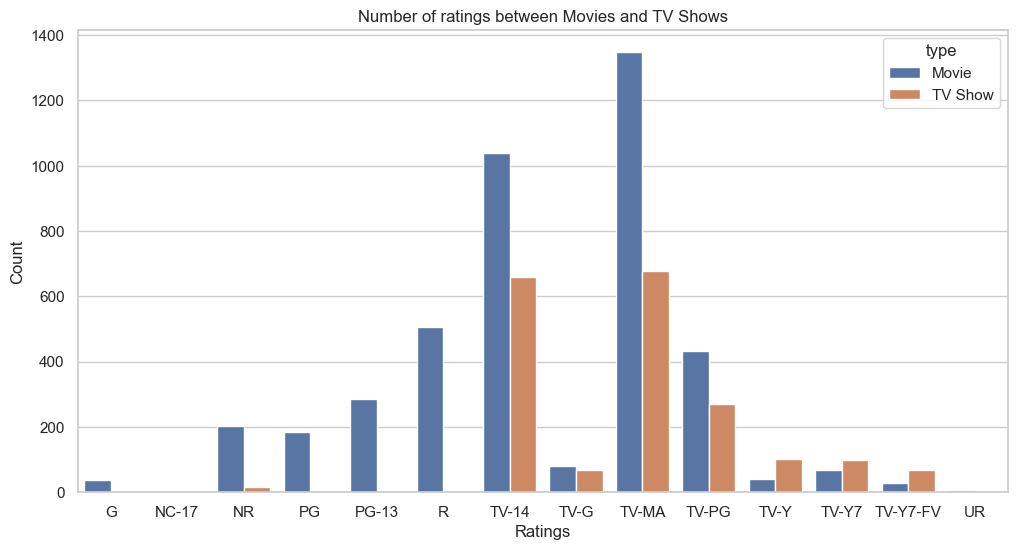

In [22]:
fig, ax = plt.subplots(figsize=(12,6))
sns.barplot(data=rating_counts, x='rating', y='count', hue='type', ax=ax)
ax.set_title('Number of ratings between Movies and TV Shows')
ax.set_xlabel('Ratings')
ax.set_ylabel('Count')
plt.show()

## Interpretation: Ratings Distribution

TV-MA and TV-14 are the most common ratings on Netflix for both Movies and TV Shows, 
confirming the platform primarily targets adult audiences. R-rated content is almost 
exclusively Movies, which makes sense given that R is a film rating while TV shows use 
a separate rating system. Interestingly, Movies dominate nearly every rating category, 
reflecting that Netflix's catalog contains roughly twice as many Movies as TV Shows overall.

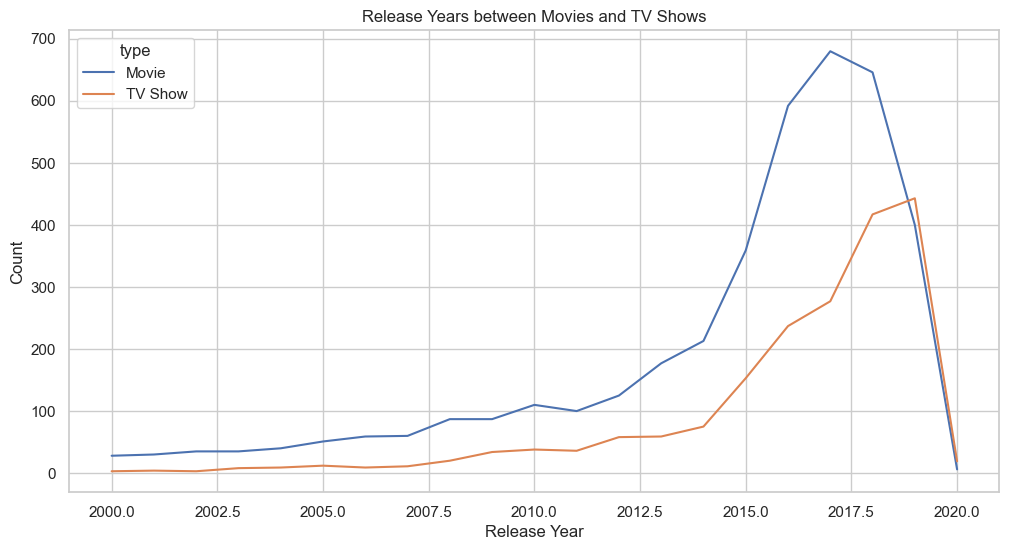

In [26]:
fig, ax = plt.subplots(figsize=(12,6))
sns.lineplot(data=trend, x='release_year', y='count', hue='type', ax=ax)
ax.set_title('Release Years between Movies and TV Shows')
ax.set_xlabel('Release Year')
ax.set_ylabel('Count')
plt.show()

## Interpretation: Release Year Trend

Both Movies and TV Shows saw massive growth in Netflix content starting around 2015, 
reflecting Netflix's aggressive content acquisition strategy. Movies peaked in 2017 
with nearly 700 titles while TV Shows continued growing through 2019. The sharp drop 
in 2020 is likely due to COVID-19 shutting down production worldwide, significantly 
reducing the number of new titles released that year.

## Summary of Findings

This analysis explored differences between Movies and TV Shows in the Netflix catalog 
using ratings distribution and release year trends as key metrics.

Movies make up the majority of Netflix's catalog at roughly 4,257 titles compared to 
1,967 TV Shows, suggesting Netflix has historically prioritized film content. Both content 
types are dominated by mature ratings — TV-MA and TV-14 — indicating that Netflix's core 
audience is adults. Notably, R-rated content is almost exclusively Movies, which aligns 
with the fact that R is a film-specific rating that does not apply to television content.

The trend analysis revealed that Netflix experienced explosive growth in content additions 
between 2015 and 2019, likely driven by aggressive licensing deals and original productions. 
Movies peaked in 2017 while TV Shows continued growing through 2019, suggesting a gradual 
strategic shift toward serialized content in recent years. The sharp decline in 2020 across 
both categories can be attributed to COVID-19 disrupting global production pipelines.

Overall, while Movies dominate Netflix's catalog in volume, TV Shows appear to be catching 
up — a trend that aligns with Netflix's increasing investment in original series and 
the broader industry shift toward streaming-first television content.